In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs()


In [4]:
df = pd.read_csv('/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nFirst few columns: {list(df.columns[:10])}")
print(f"\nTarget variable (Severity):")
print(df['Severity'].value_counts().sort_index())

Dataset loaded: 7,728,394 rows, 46 columns

First few columns: ['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)']

Target variable (Severity):
Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64


In [5]:
keep_cols = [
    'Severity', 'Start_Time', 'Distance(mi)',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Crossing', 'Junction', 'Traffic_Signal', 'Sunrise_Sunset'
]

df = df[keep_cols].copy()
print(f"\nAfter selecting columns: {df.shape}")


After selecting columns: (7728394, 14)


In [8]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek  # 0=Monday
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['IsRushHour'] = df['Hour'].isin([7,8,9,16,17,18]).astype(int)

In [9]:
for col in ['Crossing', 'Junction', 'Traffic_Signal']:
    df[col] = df[col].fillna(0).astype(int)

print(f"After cleaning: {df.shape}")
print(f"Missing values left: {df.isnull().sum().sum()}")

After cleaning: (7728394, 19)
Missing values left: 6599962


<Axes: >

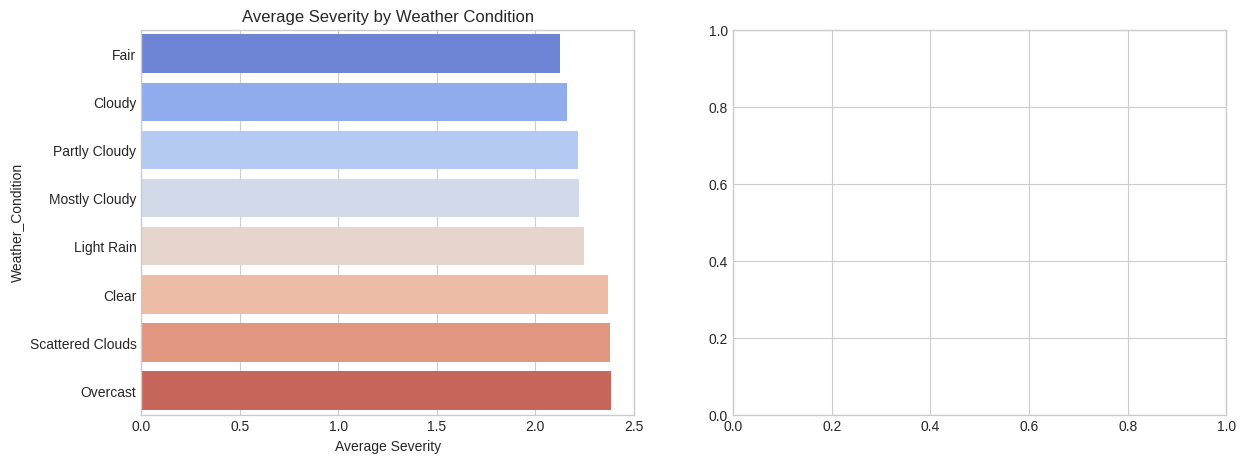

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Top 8 most common weather conditions
top_weather = df['Weather_Condition'].value_counts().head(8).index
weather_sev = df[df['Weather_Condition'].isin(top_weather)].groupby('Weather_Condition')['Severity'].mean().sort_values()
sns.barplot(x=weather_sev.values, y=weather_sev.index, palette='coolwarm')
plt.title('Average Severity by Weather Condition')
plt.xlabel('Average Severity')

plt.subplot(1, 2, 2)


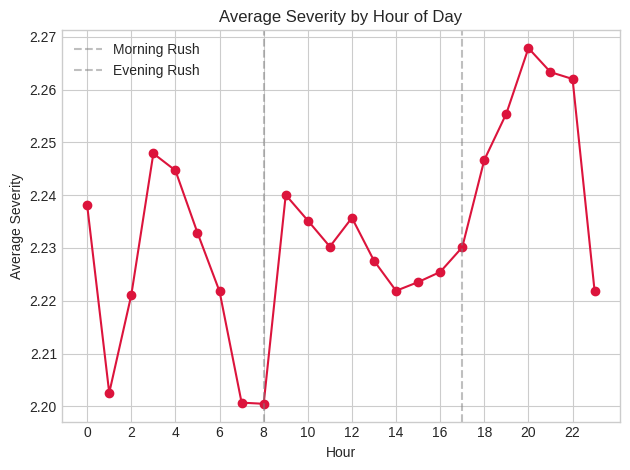

In [11]:
# Severity by hour — I expected rush hours to be worse, let's see
hourly_sev = df.groupby('Hour')['Severity'].mean()
plt.plot(hourly_sev.index, hourly_sev.values, marker='o', color='crimson')
plt.axvline(8, color='gray', linestyle='--', alpha=0.5, label='Morning Rush')
plt.axvline(17, color='gray', linestyle='--', alpha=0.5, label='Evening Rush')
plt.title('Average Severity by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Severity')
plt.legend()
plt.xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('eda_weather_time.png', dpi=150)
plt.show()



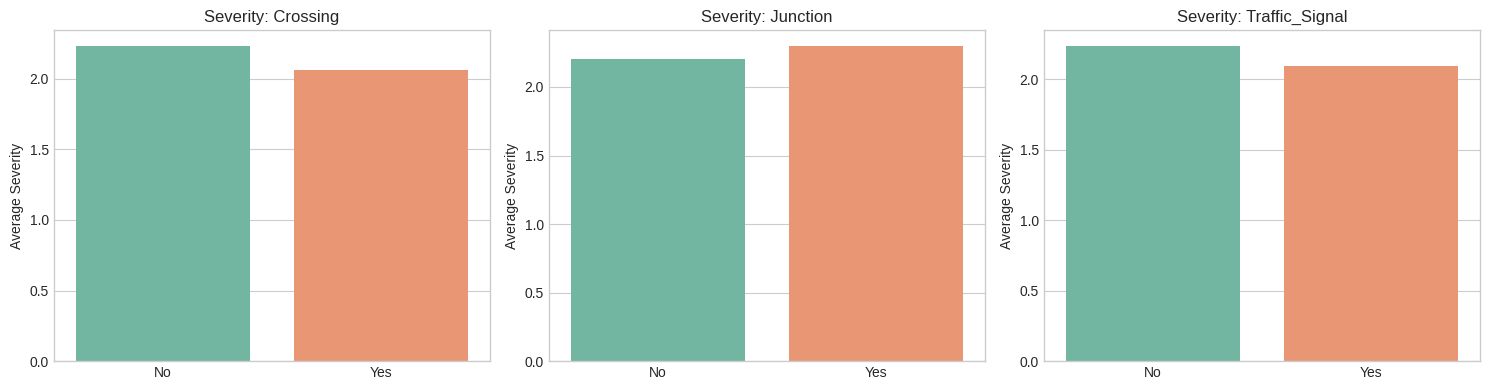

In [12]:
# Cell 6: Road features impact
# Simple question: do traffic signals and junctions change severity?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Crossing', 'Junction', 'Traffic_Signal']

for ax, feat in zip(axes, features):
    avg = df.groupby(feat)['Severity'].mean()
    sns.barplot(x=['No', 'Yes'], y=avg.values, ax=ax, palette='Set2')
    ax.set_title(f'Severity: {feat}')
    ax.set_ylabel('Average Severity')

plt.tight_layout()
plt.savefig('eda_road_features.png', dpi=150)
plt.show()

In [ ]:
# Using a sample for faster iteration; full dataset is 7.7M rows
SAMPLE_SIZE = 400_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)

# One-hot encode categoricals
df_sample = pd.get_dummies(df_sample, columns=['Weather_Condition', 'Sunrise_Sunset'],
                        drop_first=True)

# Ensure all features are numeric
df_sample = df_sample.astype({c: int for c in df_sample.select_dtypes(include='bool').columns})

X = df_sample.drop('Severity', axis=1)
y = df_sample['Severity'] - 1          # XGBoost expects classes starting at 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── 8. Train XGBoost Model ───────────────────────────────────────────────────
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

Dropping datetime columns: ['Start_Time']
Final dtypes: int64      105
float64     10
Name: count, dtype: int64


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_class=4, ...)

In [21]:
# Cell 9: Evaluate
y_pred = model.predict(X_test) + 1
y_test_orig = y_test + 1

print(f"Accuracy: {accuracy_score(y_test_orig, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test_orig, y_pred, target_names=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4']))

Accuracy: 0.806

Classification Report:
              precision    recall  f1-score   support

       Sev 1       0.65      0.07      0.12       697
       Sev 2       0.82      0.97      0.89     63660
       Sev 3       0.58      0.18      0.28     13505
       Sev 4       0.45      0.03      0.05      2138

    accuracy                           0.81     80000
   macro avg       0.62      0.31      0.34     80000
weighted avg       0.77      0.81      0.76     80000



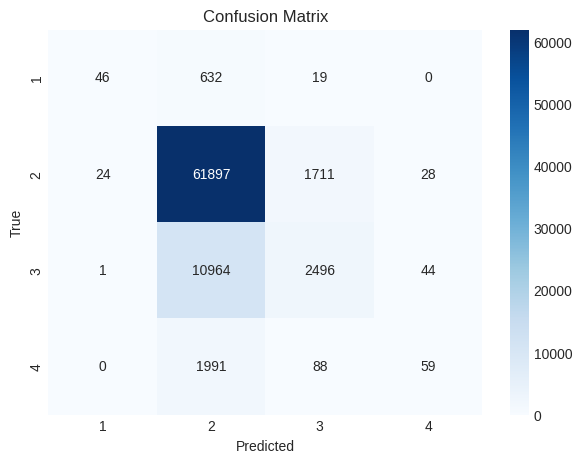

In [22]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test_orig, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=['1','2','3','4'], yticklabels=['1','2','3','4'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


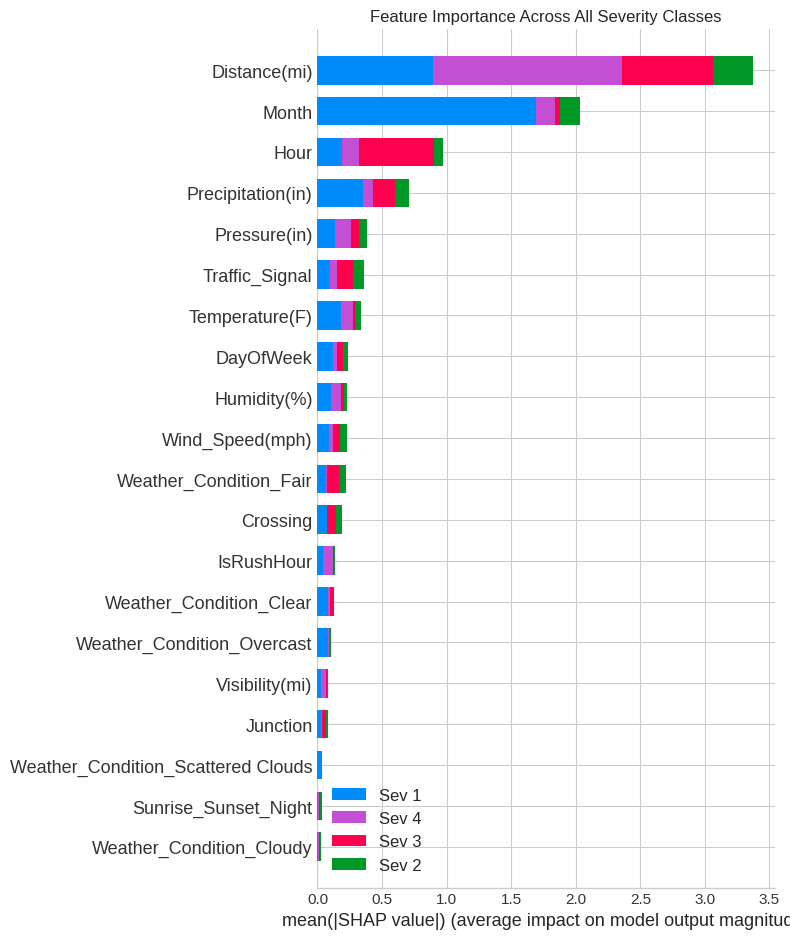

In [25]:
# Alternative SHAP approach (if the above fails)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:3000])

# For multi-class, just plot the bar chart version which is more robust
shap.summary_plot(
    shap_values, 
    X_test.iloc[:3000],
    plot_type="bar",
    class_names=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4'],
    show=False
)
plt.title('Feature Importance Across All Severity Classes')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150)
plt.show()

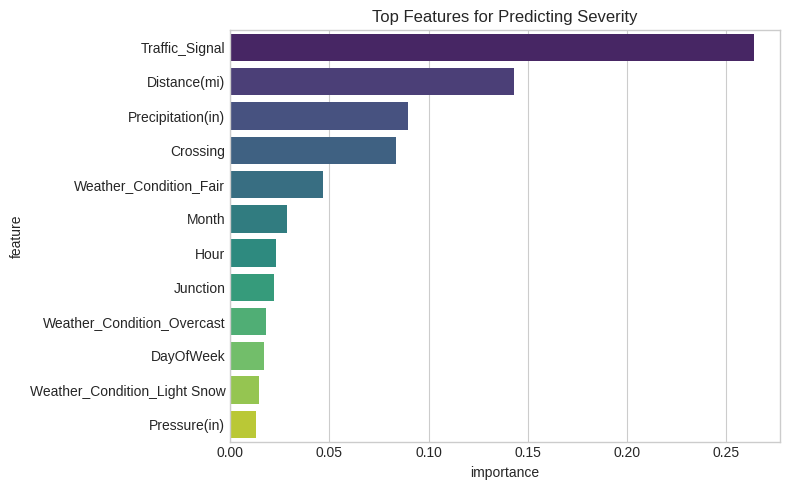

In [26]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='importance', y='feature', palette='viridis')
plt.title('Top Features for Predicting Severity')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


In [27]:
import joblib
joblib.dump(model, 'accident_severity_model.pkl')
print("Saved model!")

Saved model!


In [1]:
print("\n" + "=" * 60)
print("KEY TAKEAWAYS")
print("=" * 60)
print("""
1. Weather has a measurable but modest effect on severity.
   Overcast and foggy conditions show slightly higher average severity.

2. Time of day is less predictive than expected.
   Rush hours do not dramatically increase severity — likely due to lower speeds.

3. Road infrastructure (traffic signals, junctions, crossings) shows mixed impact.
   Traffic signals ranked highest in feature importance, which warrants deeper investigation.

4. Distance (road blockage length) and precipitation are strong severity indicators.
   Larger accidents block roads longer and correlate with more severe outcomes.

5. Limitations & Next Steps:
   • Only 400K rows used (5% of dataset) due to compute constraints
   • Severe class imbalance biases predictions toward Severity 2
   • Future: geospatial clustering, class balancing, interactive dashboard
""")
print("=" * 60)


KEY TAKEAWAYS

1. Weather has a measurable but modest effect on severity.
   Overcast and foggy conditions show slightly higher average severity.

2. Time of day is less predictive than expected.
   Rush hours do not dramatically increase severity — likely due to lower speeds.

3. Road infrastructure (traffic signals, junctions, crossings) shows mixed impact.
   Traffic signals ranked highest in feature importance, which warrants deeper investigation.

4. Distance (road blockage length) and precipitation are strong severity indicators.
   Larger accidents block roads longer and correlate with more severe outcomes.

5. Limitations & Next Steps:
   • Only 400K rows used (5% of dataset) due to compute constraints
   • Severe class imbalance biases predictions toward Severity 2
   • Future: geospatial clustering, class balancing, interactive dashboard

